In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf
import seaborn as sns
import pandas_ta as ta                      
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedeltaa
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:

ticker = "RELIANCE.NS"
data = yf.download(ticker, period="5y", interval="1d")
data.reset_index(inplace=True)
data.to_csv("reliance_5year.csv", index=False)
print(" Dataset downloaded and saved as reliance_5year.csv")
print(data.head())


In [4]:
data = pd.read_csv("reliance_5year.csv")

In [8]:
data.info

<bound method DataFrame.info of            Price               Close                High                 Low  \
0         Ticker         RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
1           Date                 NaN                 NaN                 NaN   
2     2020-09-16  1054.0235595703125  1074.3372576523657  1047.6755813917168   
3     2020-09-17  1042.3250732421875  1058.1724701146538    1039.19630018031   
4     2020-09-18  1045.4764404296875  1051.7110790333331  1032.2588818564082   
...          ...                 ...                 ...                 ...   
1236  2025-09-10              1377.0              1388.5  1374.0999755859375   
1237  2025-09-11   1383.300048828125              1385.5              1375.0   
1238  2025-09-12              1395.0   1396.300048828125              1380.5   
1239  2025-09-15   1399.300048828125   1400.800048828125  1388.5999755859375   
1240  2025-09-16   1405.300048828125              1408.0   1398.199951171875   

       

In [51]:
data = data.drop(index=[0,1])
data = data.rename(columns={'Price': 'date'})
data['date'] = pd.to_datetime(data['date'])

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')
data.loc[:, data.columns != 'date'] = data.loc[:, data.columns != 'date'].round(2)


In [52]:
data['Close_lag1'] = data['Close'].shift(1)
data['Close_lag2'] = data['Close'].shift(2)
data['Close_lag3'] = data['Close'].shift(3)
data['Close_lag5'] = data['Close'].shift(5)
data = data.dropna()
data.head()

,date,Close,High,Low,Open,Volume,Close_lag1,Close_lag2,Close_lag3,Close_lag5
7,2020-09-23,1011.51,1032.35,999.95,1024.75,42988708,1002.60,1022.87,1045.48,1054.02
8,2020-09-24,989.02,1009.34,986.69,1001.13,29826318,1011.51,1002.60,1022.87,1042.33
9,2020-09-25,998.32,1003.35,982.72,992.56,28374935,989.02,1011.51,1002.60,1045.48
10,2020-09-28,1004.92,1014.78,1000.75,1009.79,19666849,998.32,989.02,1011.51,1022.87
11,2020-09-29,1017.98,1026.57,1004.92,1008.88,25842539,1004.92,998.32,989.02,1002.60


1. Basic Data Visualization


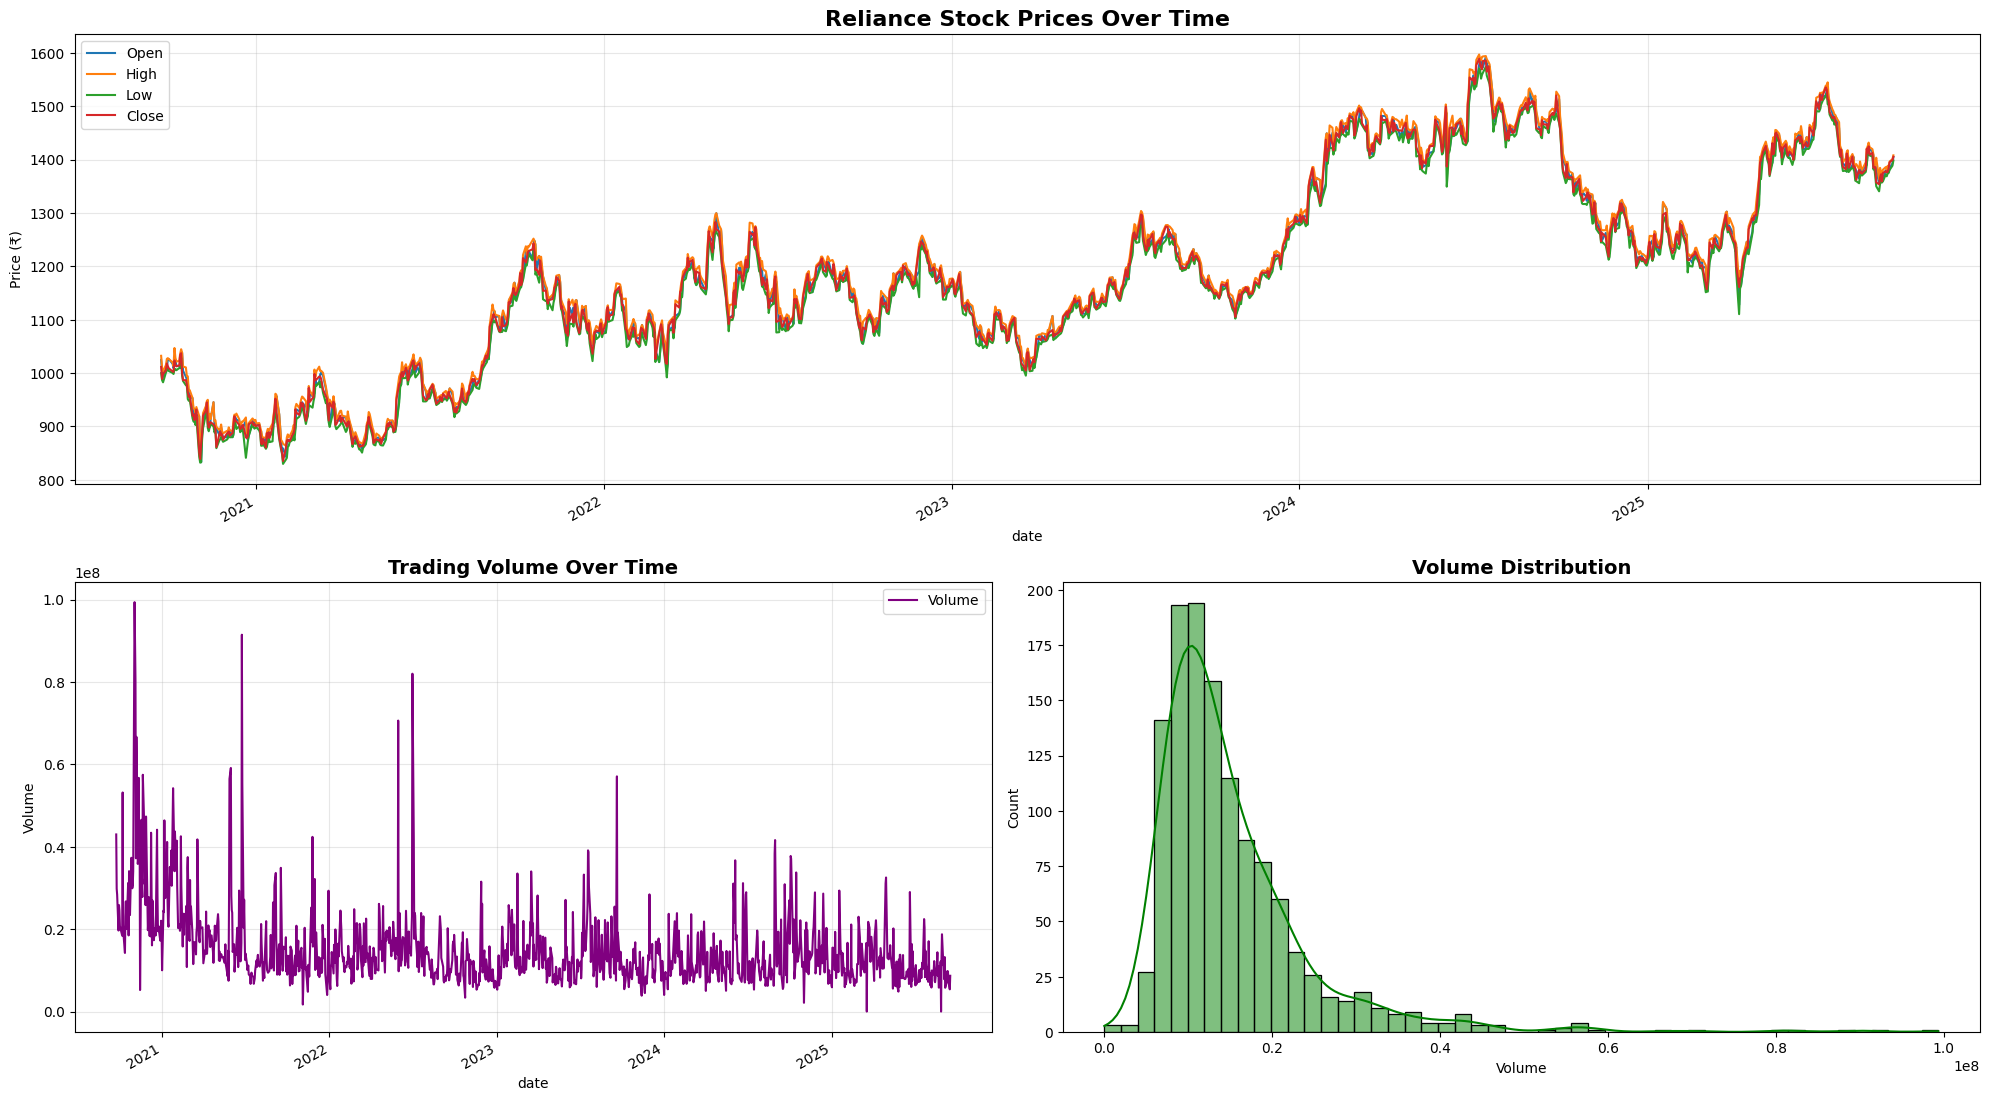

In [53]:
print("1. Basic Data Visualization")
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
data.plot(x='date', y=['Open', 'High', 'Low', 'Close'], ax=ax1)
ax1.set_title('Reliance Stock Prices Over Time', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price (₹)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Volume chart
ax2 = fig.add_subplot(gs[1, 0])
data.plot(x='date', y='Volume', ax=ax2, color='purple')
ax2.set_title('Trading Volume Over Time', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume')
ax2.grid(True, alpha=0.3)

# Volume distribution
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(data['Volume'], bins=50, kde=True, ax=ax5, color='green')
ax5.set_title('Volume Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('Volume')

plt.tight_layout()
plt.show()


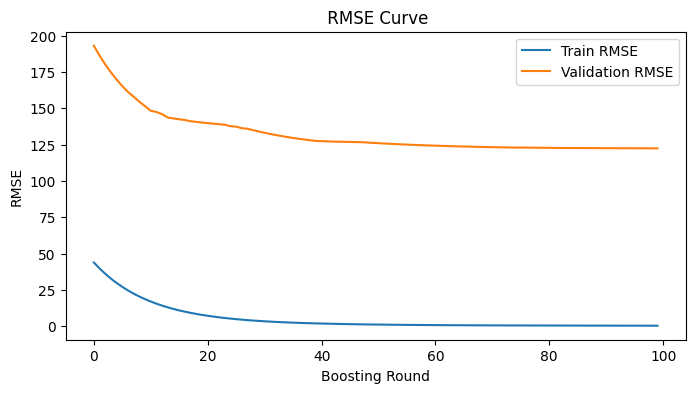

 RMSE: 122.4431, MAPE: 8.97%


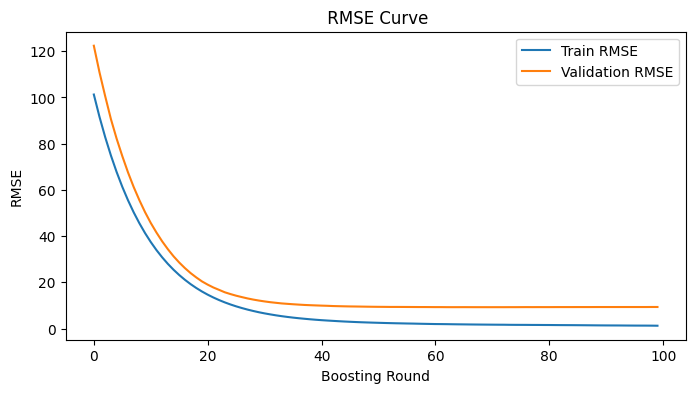

 RMSE: 9.3145, MAPE: 0.61%


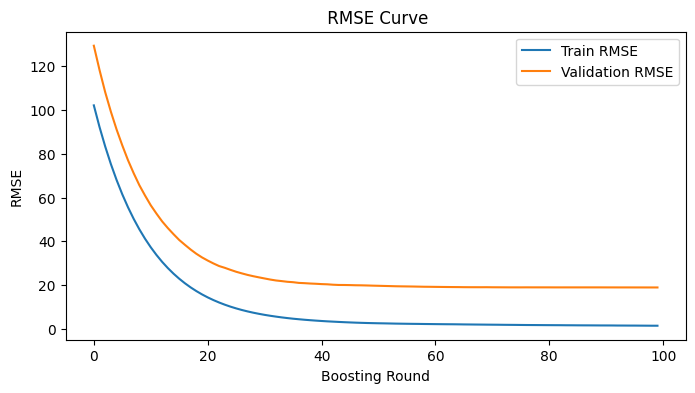

 RMSE: 18.9335, MAPE: 0.72%


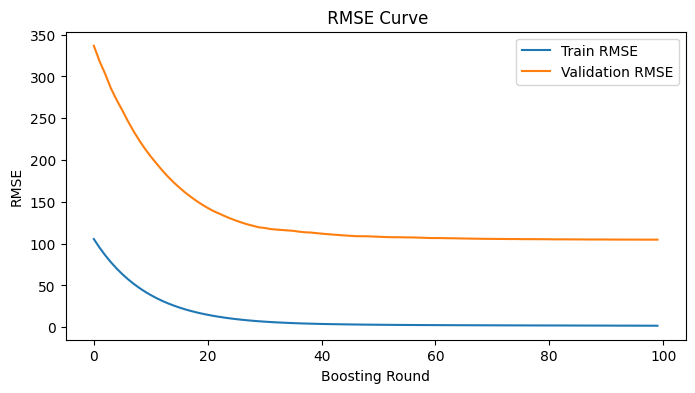

 RMSE: 104.8070, MAPE: 6.11%


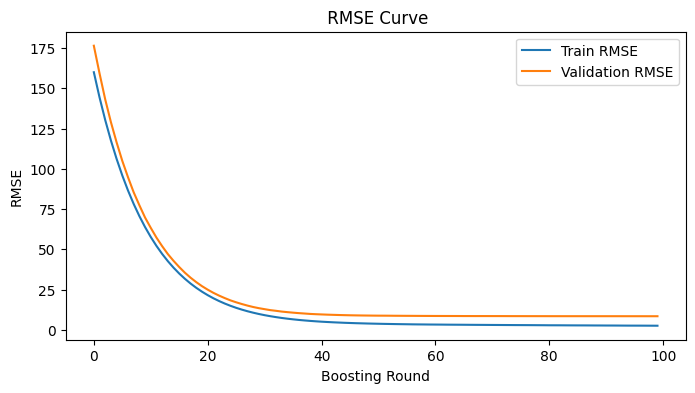

 RMSE: 8.4497, MAPE: 0.49%


In [54]:

X = data[['Open', 'High', 'Low', 'Volume', 'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag5']]
y = data['Close']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []
mape_scores = []

for train_index, val_index in tscv.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42)
    
    model.fit(
        X_train, 
        y_train, 
        eval_set=[(X_train, y_train), (X_val, y_val)], 
        verbose=False
    )
    
    results = model.evals_result()
    train_rmse_curve = results['validation_0']['rmse']
    val_rmse_curve = results['validation_1']['rmse']

    plt.figure(figsize=(8,4))
    plt.plot(train_rmse_curve, label='Train RMSE')
    plt.plot(val_rmse_curve, label='Validation RMSE')
    plt.title(' RMSE Curve')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.legend()
    plt.show()

    y_pred = model.predict(X_val)
    rmse = rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100

    rmse_scores.append(rmse)
    mape_scores.append(mape)
    print(f" RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")

    
    

In [55]:

# STEP 3: TRAIN FINAL MODEL AND PREDICT FUTURE PRICES 
final_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
final_model.fit(X_scaled, y)


# Get the last available data for starting the prediction
last_date = data['date'].iloc[-1]
last_known_X = X.iloc[-1:].copy()
previous_close = data['Close'].iloc[-1]

n_days_to_predict = 21 
future_dates = []
future_predictions = []



Final model training complete.


In [56]:
for day in range(1, n_days_to_predict + 1):
    features_to_predict = last_known_X.values
    features_scaled = scaler.transform(features_to_predict)
    
    predicted_close = final_model.predict(features_scaled)[0]
    
    next_date = last_date + timedelta(days=1)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)
    
    future_dates.append(next_date)
    future_predictions.append(predicted_close)
    
    # --- Simulate new features for the next iteration ---
    volatility = data['Close'].pct_change().std()
    random_factor = np.random.normal(0, volatility)
    
    # FIX 2: Use the 'previous_close' variable to calculate the new 'Open'.
    # This works on the first loop (using real data) and all subsequent loops (using predicted data).
    new_open = previous_close * (1 + random_factor * 0.5)
    new_high = max(new_open, predicted_close) * (1 + abs(random_factor) * 0.2)
    new_low = min(new_open, predicted_close) * (1 - abs(random_factor) * 0.2)
    new_volume = last_known_X['Volume'].iloc[0] * (1 + random_factor * 0.1)

    # FIX 3: Create the new row with a clean and simple lag update.
    # The new row should have the EXACT same columns as the original X DataFrame.
    new_row = pd.DataFrame({
        'Open': [new_open],
        'High': [new_high],
        'Low': [new_low],
        'Volume': [new_volume],
        'Close_lag1': [previous_close],  # The previous day's close is now lag 1
        'Close_lag2': [last_known_X['Close_lag1'].iloc[0]],
        'Close_lag3': [last_known_X['Close_lag2'].iloc[0]],
        'Close_lag5': [last_known_X['Close_lag3'].iloc[0]]
    })
    
    # --- Update variables for the next loop ---
    last_known_X = new_row
    last_date = next_date
    
    # FIX 4: CRUCIAL - Update 'previous_close' with the prediction we just made.
    # This new value will be used in the next iteration.
    previous_close = predicted_close

print(f"\nGenerated {len(future_predictions)} predictions.")


Generated 21 predictions.


C:\Users\Austin\jupyter-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Austin\jupyter-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Austin\jupyter-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Austin\jupyter-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Austin\jupyter-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Austin\jupy

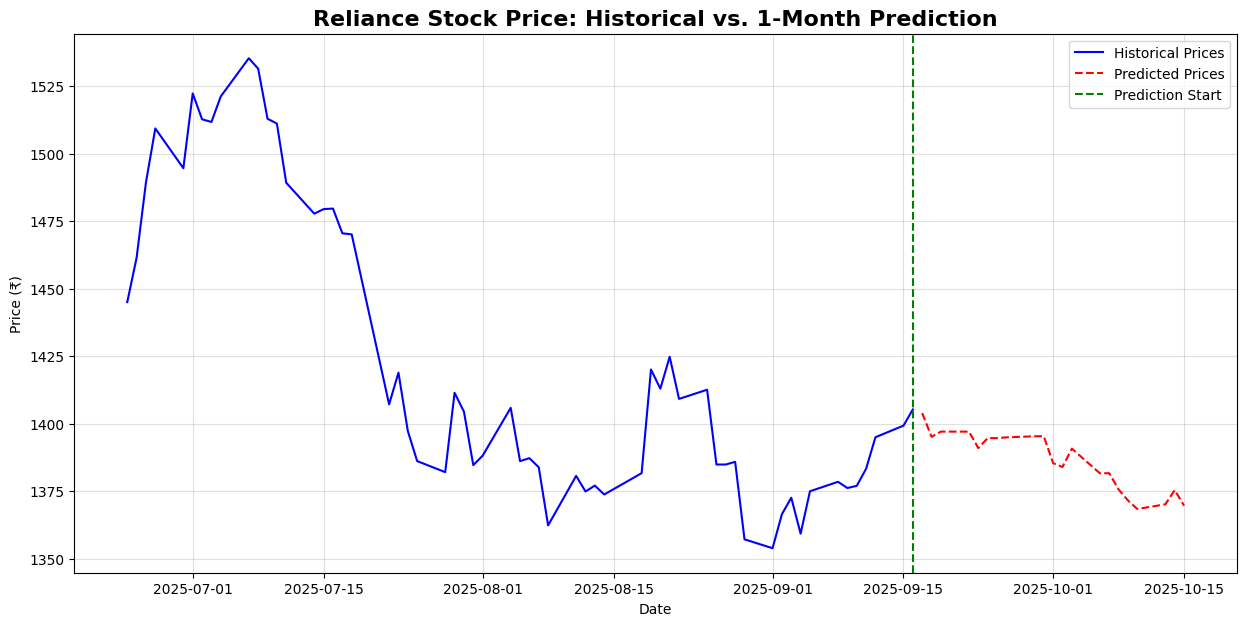


PREDICTION SUMMARY
Initial Price (Last known):       ₹1405.30
Predicted Price after 1 Month:    ₹1369.68
Predicted Change:                 -2.53%
Outlook:  BEARISH
         Date  Predicted_Close
0  2025-09-17      1403.945068
1  2025-09-18      1395.148315
2  2025-09-19      1397.086548
3  2025-09-22      1397.086548
4  2025-09-23      1390.986206
5  2025-09-24      1394.675415
6  2025-09-25      1394.675415
7  2025-09-26      1394.958374
8  2025-09-29      1395.361084
9  2025-09-30      1395.361084
10 2025-10-01      1385.408813
11 2025-10-02      1383.974854
12 2025-10-03      1390.790161
13 2025-10-06      1381.654663
14 2025-10-07      1381.678467
15 2025-10-08      1375.665527
16 2025-10-09      1371.588013
17 2025-10-10      1368.419189
18 2025-10-13      1370.157471
19 2025-10-14      1375.428223
20 2025-10-15      1369.682617


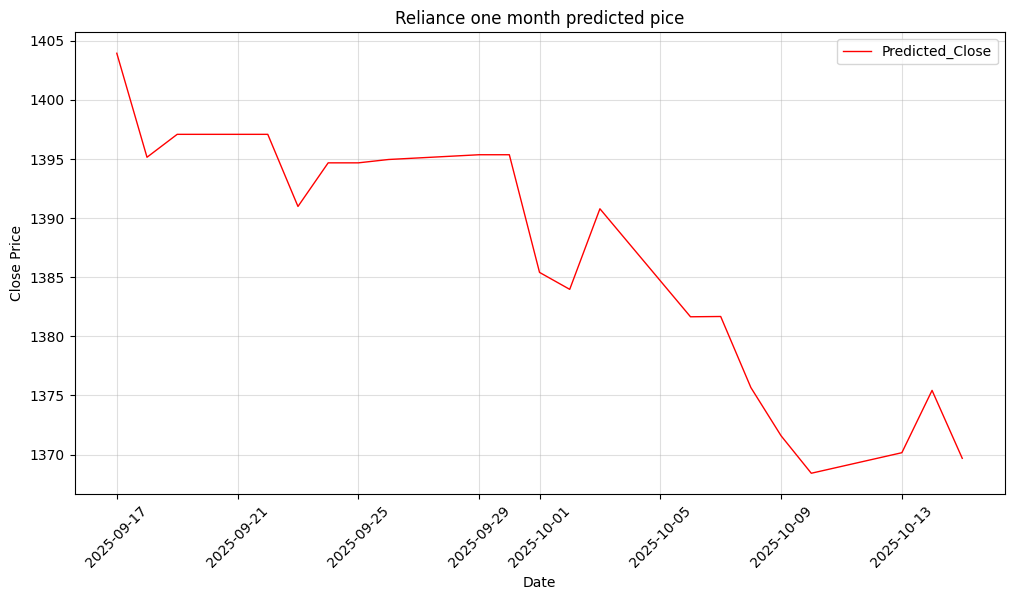

In [57]:


future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': future_predictions
})

plt.figure(figsize=(15, 7))
# Plot last 60 days of historical data
plt.plot(data['date'].iloc[-60:], data['Close'].iloc[-60:], 'b-', label='Historical Prices')
# Plot predicted data
plt.plot(future_df['Date'], future_df['Predicted_Close'], 'r--', label='Predicted Prices')

plt.title('Reliance Stock Price: Historical vs. 1-Month Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.axvline(x=data['date'].iloc[-1], color='green', linestyle='--', label='Prediction Start')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# --- Print Prediction Summary ---
initial_price = data['Close'].iloc[-1]
final_predicted_price = future_predictions[-1]
percent_change = (final_predicted_price - initial_price) / initial_price * 100

print("\n" + "="*50)
print("PREDICTION SUMMARY")
print("="*50)
print(f"Initial Price (Last known):       ₹{initial_price:.2f}")
print(f"Predicted Price after 1 Month:    ₹{final_predicted_price:.2f}")
print(f"Predicted Change:                 {percent_change:+.2f}%")

if percent_change > 0:
    print("Outlook:  BULLISH")
else:
    print("Outlook:  BEARISH")

print(future_df)

plt.figure(figsize=(12, 6))
plt.plot(future_df['Date'],future_df['Predicted_Close'],label='Predicted_Close', color='red', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Reliance one month predicted pice')
plt.legend()
plt.grid(True, alpha=0.4)
plt.xticks(rotation=45)
plt.show()


